In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.axes import Axes
import pandas as pd

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset
import os
import shutil

In [ ]:
BASE_DIR = "./Figures-V2"
MODELS_DIR = os.path.join(BASE_DIR, "models")
LOGS_DIR = os.path.join(BASE_DIR, "runs")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

print(f"Sauvegarde configurée dans : {BASE_DIR}")

Sauvegarde configurée dans : ./Figures-V2


In [ ]:
def himmel(x,y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmel_grad(x,y):
    df_dx = 4 * x * (x**2 + y - 11) + 2 * (x + y**2 - 7)
    df_dy = 2 * (x**2 + y - 11) + 4 * y * (x + y**2 - 7)
    return df_dx, df_dy

def himmel_grad_norm(x,y):
    df_dx = 4 * x * (x**2 + y - 11) + 2 * (x + y**2 - 7)
    df_dy = 2 * (x**2 + y - 11) + 4 * y * (x + y**2 - 7)
    return np.sqrt(df_dx**2 + df_dy**2)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed fixée à {seed}")

set_seed(42)

Seed fixée à 42


In [ ]:
class HimmelblauNet4(nn.Module):
    def __init__(self, nb_neurones):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class HimmelblauNet4_both(nn.Module):
    def __init__(self, nb_neurones):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, 3)
        )

    def forward(self, x):
      out = self.net(x)
      return out[:, 0:1], out[:, 1:3]

In [ ]:
class HimmelblauNet4_grad(nn.Module):
    def __init__(self, nb_neurones):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, nb_neurones),
            nn.Tanh(),
            nn.Linear(nb_neurones, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            # La loss n'a pas baissé de plus de min_delta -> On compte
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # La loss a baissé significativement -> On reset le compteur et on sauvegarde
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

#params
DOMAIN_LOW = -4.0
DOMAIN_HIGH = 4.0
N_TRAIN_LIST = [250, 500, 1000, 5000, 10000, 20000]
N_REPEATS = 30
N_TEST = 10000
MAX_EPOCHS = 5000
LR_FIXE = 0.005

BATCH_SIZES = {
    250: 250,    500: 500,    1000: 1000,
    5000: 2500,  10000: 2500, 20000: 2500
}

LAMBDA_AUTODIFF = 19.0
LAMBDA_MULTITASK = 1.0

BASE_DIR = "."
CHECKPOINT_CSV = os.path.join(BASE_DIR, "Reproduction_Himmelblau_Final-V2.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mae_criterion = nn.L1Loss()
mse_criterion = nn.MSELoss()

model_classes = {
    "Classic": HimmelblauNet4,
    "Both auto-diff": HimmelblauNet4,
    "Both multitask": HimmelblauNet4_both,
    "Gradient": HimmelblauNet4
}

if os.path.exists(CHECKPOINT_CSV):
    os.remove(CHECKPOINT_CSV)
    print("Ancien fichier CSV supprimé")

def generate_combined_data(n_points, low=-4.0, high=4.0):
    X_raw = torch.rand(n_points, 2) * (high - low) + low
    X_norm = X_raw / 4.0

    y_raw_class = himmel(X_raw[:, 0], X_raw[:, 1]).unsqueeze(1)
    df_dx, df_dy = himmel_grad(X_raw[:, 0], X_raw[:, 1])
    y_raw_grad = torch.stack([df_dx, df_dy], dim=1)

    search_space = torch.linspace(low, high, 1000)
    grid_x, grid_y = torch.meshgrid(search_space, search_space, indexing='xy')
    max_val_class = torch.max(himmel(grid_x, grid_y)).item()
    grad_x_grid, grad_y_grid = himmel_grad(grid_x, grid_y)
    max_val_grad = torch.max(torch.abs(torch.stack([grad_x_grid, grad_y_grid]))).item()

    y_norm_class = y_raw_class / max_val_class
    y_norm_grad = y_raw_grad / max_val_grad

    if torch.cuda.is_available():
        return X_norm.cuda(), y_norm_class.cuda(), y_norm_grad.cuda(), max_val_class, max_val_grad
    return X_norm, y_norm_class, y_norm_grad, max_val_class, max_val_grad

print(f"Génération du Dataset de Test ({N_TEST} points)")
X_test, y_test_class, y_test_grad, MAX_VAL_CLASS, MAX_VAL_GRAD = generate_combined_data(N_TEST, DOMAIN_LOW, DOMAIN_HIGH)

print(f"Génération du Dataset de Validation (2000 points) pour EarlyStopping")
X_val, y_val_class, y_val_grad, _, _ = generate_combined_data(2000, DOMAIN_LOW, DOMAIN_HIGH)
X_val_req = X_val.clone().detach().requires_grad_(True)


#boucle
print(f"Démarrage du Grand Run (4 Stratégies, Scheduler & Early Stopping).")

for n_samples in tqdm(N_TRAIN_LIST, desc="Tailles de Dataset"):

    for repeat in tqdm(range(N_REPEATS), desc=f"N={n_samples}", leave=False):
        current_results = []

        X_train, y_train_class, y_train_grad, _, _ = generate_combined_data(n_samples, DOMAIN_LOW, DOMAIN_HIGH)
        train_dataset = TensorDataset(X_train, y_train_class, y_train_grad)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZES[n_samples], shuffle=True)

        for run_type in ["Classic", "Both auto-diff", "Both multitask", "Gradient"]:

            model = model_classes[run_type](nb_neurones=16).to(device)
            optimizer = optim.Adam(model.parameters(), lr=LR_FIXE)

            # Scheduler
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=20, min_lr=1e-6)

            # EarlyStopping
            checkpoint_path = f"best_model_final_{run_type.replace(' ', '_')}.pt"
            early_stopping = EarlyStopping(patience=100, min_delta=1e-8, path=checkpoint_path)

            #training
            start_time = time.time()

            for epoch in range(MAX_EPOCHS):
                model.train()
                for X_batch, y_class_batch, y_grad_batch in train_loader:
                    optimizer.zero_grad()
                    X_batch_req = X_batch.clone().detach().requires_grad_(True)

                    if run_type == "Classic":
                        preds_energy = model(X_batch_req)
                        loss = mse_criterion(preds_energy, y_class_batch)

                    elif run_type == "Both auto-diff":
                        preds_energy = model(X_batch_req)
                        preds_grad = torch.autograd.grad(
                            outputs=preds_energy, inputs=X_batch_req, grad_outputs=torch.ones_like(preds_energy), create_graph=True
                        )[0]
                        scaled_preds_grad = preds_grad * (MAX_VAL_CLASS / 4.0) / MAX_VAL_GRAD
                        loss = mse_criterion(preds_energy, y_class_batch) + LAMBDA_AUTODIFF * mse_criterion(scaled_preds_grad, y_grad_batch)

                    elif run_type == "Both multitask":
                        preds_energy, preds_grad = model(X_batch_req)
                        loss = mse_criterion(preds_energy, y_class_batch) + LAMBDA_MULTITASK * mse_criterion(preds_grad, y_grad_batch)

                    elif run_type == "Gradient":
                        preds_energy = model(X_batch_req)
                        preds_grad = torch.autograd.grad(
                            outputs=preds_energy, inputs=X_batch_req, grad_outputs=torch.ones_like(preds_energy), create_graph=True
                        )[0]
                        scaled_preds_grad = preds_grad * (MAX_VAL_CLASS / 4.0) / MAX_VAL_GRAD
                        loss = mse_criterion(scaled_preds_grad, y_grad_batch)

                    loss.backward()
                    optimizer.step()

                #validation
                model.eval()
                with torch.set_grad_enabled(True):
                    if run_type == "Classic":
                        preds_val = model(X_val_req)
                        val_loss = mse_criterion(preds_val, y_val_class).item()

                    elif run_type == "Both auto-diff":
                        preds_val = model(X_val_req)
                        grad_val = torch.autograd.grad(outputs=preds_val, inputs=X_val_req, grad_outputs=torch.ones_like(preds_val), create_graph=False)[0]
                        scaled_grad_val = grad_val * (MAX_VAL_CLASS / 4.0) / MAX_VAL_GRAD
                        val_loss = (mse_criterion(preds_val, y_val_class) + mse_criterion(scaled_grad_val, y_val_grad)).item()

                    elif run_type == "Both multitask":
                        preds_val, grad_val = model(X_val_req)
                        val_loss = (mse_criterion(preds_val, y_val_class) + mse_criterion(grad_val, y_val_grad)).item()

                    elif run_type == "Gradient":
                        preds_val = model(X_val_req)
                        grad_val = torch.autograd.grad(outputs=preds_val, inputs=X_val_req, grad_outputs=torch.ones_like(preds_val), create_graph=False)[0]
                        scaled_grad_val = grad_val * (MAX_VAL_CLASS / 4.0) / MAX_VAL_GRAD
                        val_loss = mse_criterion(scaled_grad_val, y_val_grad).item()

                scheduler.step(val_loss)
                early_stopping(val_loss, model)

                if early_stopping.early_stop:
                    break

            train_time = round(time.time() - start_time, 2)
            epochs_run = epoch + 1
            final_lr = optimizer.param_groups[0]['lr']

            #best modele
            model.load_state_dict(torch.load(checkpoint_path, weights_only=True))

            #calcul constante
            optimal_C = 0.0
            if run_type == "Gradient":
                model.eval()
                with torch.no_grad():
                    preds_train_energy = model(X_train) * MAX_VAL_CLASS
                    real_train_targets = y_train_class * MAX_VAL_CLASS
                    diff = real_train_targets - preds_train_energy
                    optimal_C = torch.median(diff).item()

            #test
            model.eval()
            X_test_req = X_test.clone().detach().requires_grad_(True)

            with torch.set_grad_enabled(True):
                if run_type in ["Classic", "Both auto-diff", "Gradient"]:
                    preds_energy_norm = model(X_test_req)

                    # On décale les énergies avec C
                    real_preds_energy = (preds_energy_norm * MAX_VAL_CLASS) + optimal_C
                    real_targets_energy = y_test_class * MAX_VAL_CLASS
                    mae_func_real = mae_criterion(real_preds_energy, real_targets_energy).item()

                    grad_preds = torch.autograd.grad(
                        outputs=preds_energy_norm, inputs=X_test_req, grad_outputs=torch.ones_like(preds_energy_norm), create_graph=False
                    )[0]
                    real_grad_preds = grad_preds * (MAX_VAL_CLASS / 4.0)
                    real_grad_targets = y_test_grad * MAX_VAL_GRAD
                    mae_grad_real = mae_criterion(real_grad_preds, real_grad_targets).item()

                elif run_type == "Both multitask":
                    preds_energy_norm, p_grad = model(X_test_req)

                    real_preds_energy = preds_energy_norm * MAX_VAL_CLASS
                    real_targets_energy = y_test_class * MAX_VAL_CLASS
                    mae_func_real = mae_criterion(real_preds_energy, real_targets_energy).item()

                    real_grad_preds = p_grad * MAX_VAL_GRAD
                    real_grad_targets = y_test_grad * MAX_VAL_GRAD
                    mae_grad_real = mae_criterion(real_grad_preds, real_grad_targets).item()

            #sauvegarde
            current_results.append({
                "Training_Labels": n_samples,
                "Repeat": repeat,
                "Strategy": run_type,
                "MAE_Energy": mae_func_real,
                "MAE_Force": mae_grad_real,
                "Epochs": epochs_run,
                "Final_LR": final_lr,
                "Time_Seconds": train_time
            })

        df_current = pd.DataFrame(current_results)
        if not os.path.isfile(CHECKPOINT_CSV):
            df_current.to_csv(CHECKPOINT_CSV, index=False, mode='w')
        else:
            df_current.to_csv(CHECKPOINT_CSV, index=False, mode='a', header=False)

print("\nEntraînements terminés.")

⚙️ Génération du Dataset de Test (10000 points)...
⚙️ Génération du Dataset de Validation (2000 points) pour EarlyStopping...
🚀 Démarrage du Grand Run (4 Stratégies, Scheduler & Early Stopping).


Tailles de Dataset:   0%|          | 0/6 [00:00<?, ?it/s]

N=250:   0%|          | 0/30 [00:00<?, ?it/s]

N=500:   0%|          | 0/30 [00:00<?, ?it/s]

N=1000:   0%|          | 0/30 [00:00<?, ?it/s]

N=5000:   0%|          | 0/30 [00:00<?, ?it/s]

N=10000:   0%|          | 0/30 [00:00<?, ?it/s]

N=20000:   0%|          | 0/30 [00:00<?, ?it/s]


✅ Entraînements terminés ! Le fichier 'Reproduction_Himmelblau_Final-V2.csv' est prêt avec toutes les métadonnées !


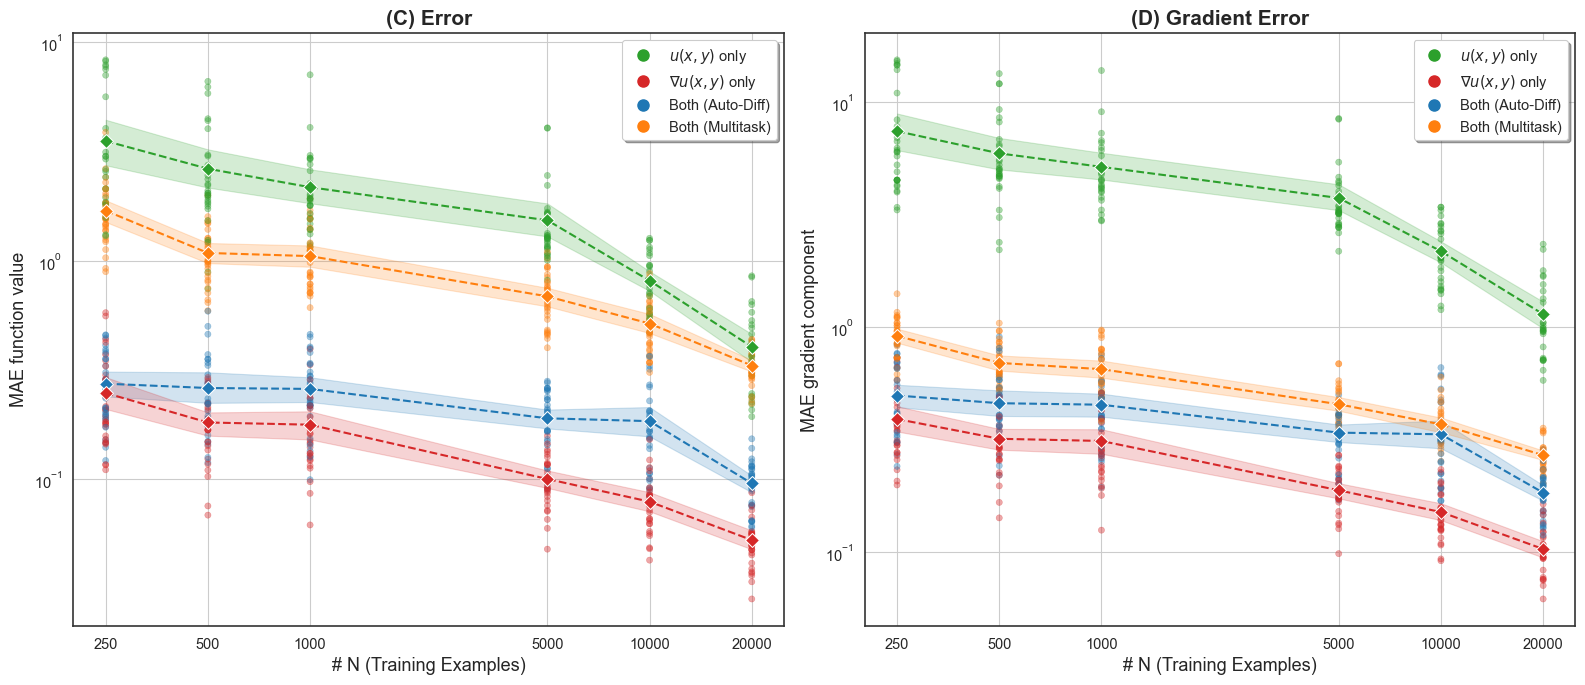

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
df_res = pd.read_csv(CHECKPOINT_CSV)

strategy_mapping = {
    'Classic': '$u(x,y)$ only',
    'Gradient': '$\\nabla u(x,y)$ only',
    'Both auto-diff': 'Both (Auto-Diff)',
    'Both multitask': 'Both (Multitask)'
}
df_res['Strategy_Name'] = df_res['Strategy'].map(strategy_mapping)

palette = {
    '$u(x,y)$ only': '#2ca02c',          # Vert
    '$\\nabla u(x,y)$ only': '#d62728',  # Rouge
    'Both (Auto-Diff)': '#1f77b4',       # Bleu
    'Both (Multitask)': '#ff7f0e'        # Orange
}

n_ticks = [250, 500, 1000, 5000, 10000, 20000]

custom_lines = [Line2D([0], [0], color=color, lw=0, marker='o', markersize=8) for color in palette.values()]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2,
              rc={"axes.edgecolor": "0.2", "axes.linewidth": 1.2})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]

sns.scatterplot(data=df_res, x="Training_Labels", y="MAE_Energy", hue="Strategy_Name",
                palette=palette, alpha=0.40, s=20, edgecolor=None, ax=ax, legend=False)

sns.lineplot(data=df_res, x="Training_Labels", y="MAE_Energy", hue="Strategy_Name",
             palette=palette, errorbar=("ci", 95), err_style="band",
             linewidth=1.5, linestyle="--", marker="D", markersize=7,
             markeredgecolor="white", ax=ax, legend=False)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(n_ticks)
ax.set_xticklabels(n_ticks)
ax.set_xticks([], minor=True)
ax.set_title("(C) Error", fontsize=15, fontweight='bold')
ax.set_xlabel("# N (Training Examples)", fontsize=13)
ax.set_ylabel("MAE function value", fontsize=13)
ax.legend(custom_lines, palette.keys(), loc="upper right", frameon=True, shadow=True)

ax = axes[1]

sns.scatterplot(data=df_res, x="Training_Labels", y="MAE_Force", hue="Strategy_Name",
                palette=palette, alpha=0.40, s=20, edgecolor=None, ax=ax, legend=False)

sns.lineplot(data=df_res, x="Training_Labels", y="MAE_Force", hue="Strategy_Name",
             palette=palette, errorbar=("ci", 95), err_style="band",
             linewidth=1.5, linestyle="--", marker="D", markersize=7,
             markeredgecolor="white", ax=ax, legend=False)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(n_ticks)
ax.set_xticklabels(n_ticks)
ax.set_xticks([], minor=True)
ax.set_title("(D) Gradient Error", fontsize=15, fontweight='bold')
ax.set_xlabel("# N (Training Examples)", fontsize=13)
ax.set_ylabel("MAE gradient component", fontsize=13)
ax.legend(custom_lines, palette.keys(), loc="upper right", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "Figures_IC-V3.png"), dpi=300, bbox_inches="tight")
plt.show()